# GSE245998 multiome QC and AnnData initialization

This notebook prepares the six paired snRNA-seq/snATAC-seq samples from
[GSE245998](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE245998).
It follows the QC logic released with
[Bulger et al., 2024](https://doi.org/10.1242/dev.202516) and the authors'
[TBXT-CDX2-Analysis](https://github.com/ebulger3/TBXT-CDX2-Analysis)
R Markdown, while keeping the output in the scverse ecosystem.

Outputs:

- `gse245998_rna_qc.h5ad`: paired-nucleus RNA counts after the selected QC profile
- `gse245998_atac_cell_qc.h5ad`: ATAC cell metrics and fragment-file registry (no peak matrix)
- `gse245998_multiome_qc.h5mu`: RNA plus the paired ATAC cell-QC modality
- one retained-barcode file per sample for later consensus-peak counting

The sample H5 files contain independently called ATAC peak sets. They must not be
concatenated directly. A later notebook should construct a common tile or consensus-peak
matrix from the fragment files.


## Method correspondence and caveats

The paper used:

- RNA: Seurat with 5,000–12,500 UMIs, 2,500–4,500 detected genes,
  5–20% mitochondrial reads, and 3–15% ribosomal reads.
- ATAC: ArchR Arrow files with `minTSS=4` and `minFrags=1000`.
- Doublets: ArchR `addDoubletScores()` followed by `filterDoublets()`.
- Final cells: intersection of the RNA and ATAC retained barcodes.

This notebook reproduces the RNA thresholds exactly and counts unique fragment rows,
matching ArchR's `nFrags` convention. TSS enrichment is computed from strand-aware
GENCODE v32 TSS positions with Muon's ENCODE-style implementation. Doublets are called
per sample with Scanpy/Scrublet, so TSS and doublet calls should be compared with the
authors' reported distributions rather than assumed to be bit-identical to ArchR.

The authors' lower bounds on mitochondrial and ribosomal fractions are unusual and could
remove biologically interesting low-RNA nuclei. Both the exact author mask and a less
restrictive basic mask are retained in `.obs`; choose the profile in the configuration
cell after inspecting the plots.


In [29]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import gzip
import os
import urllib.request

import anndata as ad
import h5py
import matplotlib.pyplot as plt
import mudata as md
import muon as mu
import numpy as np
import pandas as pd
import pysam
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5), dpi=100, frameon=False)
sns.set_theme(style="whitegrid")

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

RAW_DIR = REPO / "data" / "GSE245998" / "raw"
REFERENCE_DIR = REPO / "data" / "GSE245998" / "reference"
OUTPUT_DIR = REPO / "data" / "GSE245998" / "processed"
BARCODE_DIR = OUTPUT_DIR / "barcodes"

# Set GSE245998_SMOKE_TEST=1 when executing non-interactively for a quick code-path check.
SMOKE_TEST = os.environ.get("GSE245998_SMOKE_TEST", "0") == "1"
RUN_FRAGMENT_QC = not SMOKE_TEST
RUN_TSS_QC = not SMOKE_TEST
RUN_DOUBLET_QC = not SMOKE_TEST
WRITE_OUTPUTS = not SMOKE_TEST

# "author" reproduces the paper's explicit RNA bounds; "basic" avoids its unusual
# lower mito/ribo bounds. Both masks are always retained in obs.
QC_PROFILE = "author"
TSS_N_SITES = 2_000
RANDOM_STATE = 0

AUTHOR_RNA_QC = {
    "min_counts": 5_000,
    "max_counts": 12_500,
    "min_genes": 2_500,
    "max_genes": 4_500,
    "min_pct_mt": 5.0,
    "max_pct_mt": 20.0,
    "min_pct_ribo": 3.0,
    "max_pct_ribo": 15.0,
}
BASIC_RNA_QC = {
    "min_counts": 1_000,
    "max_counts": np.inf,
    "min_genes": 200,
    "max_genes": np.inf,
    "min_pct_mt": 0.0,
    "max_pct_mt": 20.0,
    "min_pct_ribo": 0.0,
    "max_pct_ribo": 100.0,
}
ATAC_QC = {"min_fragments": 1_000, "min_tss": 2.0} # note: the author used 4.0 for archR

for path in (REFERENCE_DIR, OUTPUT_DIR, BARCODE_DIR):
    path.mkdir(parents=True, exist_ok=True)

print(f"Repository: {REPO}")
print(f"Smoke test: {SMOKE_TEST}")


Repository: /home/stan/Git/micropattern
Smoke test: False


## Sample manifest


In [2]:
sample_manifest = pd.DataFrame.from_records(
    [
        ("eb01", "GSM7853050", "GSM7853056", "WT", "1", "WT-1"),
        ("eb02", "GSM7853051", "GSM7853057", "TBXT-KO", "1", "TBXT-KO-1"),
        ("eb03", "GSM7853052", "GSM7853058", "TBXT-Het", "1", "TBXT-Het-1"),
        ("eb06", "GSM7853053", "GSM7853059", "WT", "2", "WT-2"),
        ("eb07", "GSM7853054", "GSM7853060", "TBXT-KO", "2", "TBXT-KO-2"),
        ("eb08", "GSM7853055", "GSM7853061", "TBXT-Het", "2", "TBXT-Het-2"),
    ],
    columns=[
        "sample",
        "h5_accession",
        "fragments_accession",
        "genotype",
        "batch",
        "sample_name",
    ],
).set_index("sample")

sample_manifest["h5"] = [
    RAW_DIR / f"{row.h5_accession}_{sample}_filtered_feature_bc_matrix.h5"
    for sample, row in sample_manifest.iterrows()
]
sample_manifest["fragments"] = [
    RAW_DIR / f"{row.fragments_accession}_{sample}_atac_fragments.tsv.gz"
    for sample, row in sample_manifest.iterrows()
]

if SMOKE_TEST:
    sample_manifest = sample_manifest.iloc[:1].copy()

missing = [
    str(path)
    for path in sample_manifest[["h5", "fragments"]].to_numpy().ravel()
    if not Path(path).is_file()
]
if missing:
    raise FileNotFoundError("Missing inputs:\n" + "\n".join(missing))

sample_manifest


,h5_accession,fragments_accession,genotype,batch,sample_name,h5,fragments
sample,,,,,,,
eb01,GSM7853050,GSM7853056,WT,1,WT-1,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...
eb02,GSM7853051,GSM7853057,TBXT-KO,1,TBXT-KO-1,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...
eb03,GSM7853052,GSM7853058,TBXT-Het,1,TBXT-Het-1,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...
eb06,GSM7853053,GSM7853059,WT,2,WT-2,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...
eb07,GSM7853054,GSM7853060,TBXT-KO,2,TBXT-KO-2,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...
eb08,GSM7853055,GSM7853061,TBXT-Het,2,TBXT-Het-2,/home/stan/Git/micropattern/data/GSE245998/raw...,/home/stan/Git/micropattern/data/GSE245998/raw...


## Confirm the ATAC feature-space mismatch

Cell Ranger ARC called peaks independently in each library. Exact peak-name overlap is
checked from HDF5 metadata without loading the matrices. The union is useful only as a
diagnostic; it is not an appropriate integrated feature space.


In [3]:
def h5_peak_names(path: Path) -> set[str]:
    with h5py.File(path, "r") as handle:
        feature_type = handle["matrix/features/feature_type"][:].astype(str)
        names = handle["matrix/features/name"][:].astype(str)
    return set(names[feature_type == "Peaks"])


peak_sets = {
    sample: h5_peak_names(Path(row.h5))
    for sample, row in sample_manifest.iterrows()
}
peak_space_summary = pd.DataFrame(
    {"n_sample_peaks": {sample: len(peaks) for sample, peaks in peak_sets.items()}}
)
if len(peak_sets) > 1:
    peak_space_summary.attrs["n_exact_common_peaks"] = len(
        set.intersection(*peak_sets.values())
    )
    peak_space_summary.attrs["n_union_peaks"] = len(
        set.union(*peak_sets.values())
    )
peak_space_summary, peak_space_summary.attrs


(      n_sample_peaks
 eb01          206041
 eb02          263714
 eb03          270407
 eb06          281402
 eb07          266932
 eb08          272361,
 {'n_exact_common_peaks': 0, 'n_union_peaks': 1558964})

## Helpers


In [4]:
GENCODE_GTF_URL = (
    "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/"
    "release_32/gencode.v32.annotation.gtf.gz"
)
GENCODE_GTF = REFERENCE_DIR / "gencode.v32.annotation.gtf.gz"


def ensure_gencode_gtf(path: Path = GENCODE_GTF) -> Path:
    if path.is_file():
        return path
    temporary = path.with_suffix(path.suffix + ".part")
    print(f"Downloading {GENCODE_GTF_URL}")
    urllib.request.urlretrieve(GENCODE_GTF_URL, temporary)
    temporary.replace(path)
    return path


def read_gene_tss(gtf_path: Path) -> pd.DataFrame:
    records = []
    with gzip.open(gtf_path, "rt") as handle:
        for line in handle:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) != 9 or fields[2] != "gene":
                continue
            chrom, start, end, strand = (
                fields[0],
                int(fields[3]) - 1,
                int(fields[4]) - 1,
                fields[6],
            )
            tss = start if strand == "+" else end
            records.append((chrom, tss, tss + 1, strand))
    return pd.DataFrame(
        records, columns=["Chromosome", "Start", "End", "Strand"]
    ).drop_duplicates(["Chromosome", "Start", "Strand"])


def ensure_tabix_index(fragment_path: Path) -> Path:
    index = Path(f"{fragment_path}.tbi")
    if not index.is_file():
        print(f"Creating tabix index for {fragment_path.name}")
        # GEO provides BGZF-compressed fragment files but not their .tbi indexes.
        pysam.tabix_index(
            str(fragment_path),
            preset="bed",
            force=False,
            keep_original=True,
        )
    return index


def add_sample_metadata(adata: ad.AnnData, sample: str, row: pd.Series) -> None:
    adata.obs["barcode"] = adata.obs_names.astype(str)
    adata.obs["sample"] = sample
    adata.obs["sample_name"] = row.sample_name
    adata.obs["genotype"] = row.genotype
    adata.obs["batch"] = str(row.batch)


def add_matrix_qc(mdata: md.MuData, sample: str, row: pd.Series) -> None:
    rna = mdata.mod["rna"]
    atac = mdata.mod["atac"]

    rna.var["gene_symbol"] = rna.var_names.astype(str)
    rna.var_names_make_unique()
    atac.var_names_make_unique()

    add_sample_metadata(rna, sample, row)
    add_sample_metadata(atac, sample, row)

    rna.var["mt"] = rna.var["gene_symbol"].str.startswith("MT-")
    rna.var["ribo"] = rna.var["gene_symbol"].str.startswith(("RPS", "RPL"))
    sc.pp.calculate_qc_metrics(
        rna,
        qc_vars=["mt", "ribo"],
        percent_top=None,
        log1p=False,
        inplace=True,
    )
    sc.pp.calculate_qc_metrics(
        atac,
        percent_top=None,
        log1p=False,
        inplace=True,
    )


def unique_fragment_metrics(
    fragment_path: Path, barcodes: pd.Index
) -> pd.DataFrame:
    keep = set(barcodes.astype(str))
    n_fragments = Counter()
    nucleosome_free = Counter()
    mononucleosome = Counter()

    with pysam.TabixFile(str(fragment_path), parser=pysam.asBed()) as fragments:
        for fragment in fragments.fetch():
            barcode = fragment.name
            if barcode not in keep:
                continue
            # ArchR nFrags counts fragment rows, not the duplicate/read-support field.
            n_fragments[barcode] += 1
            length = fragment.end - fragment.start
            if length < 147:
                nucleosome_free[barcode] += 1
            elif length < 294:
                mononucleosome[barcode] += 1

    result = pd.DataFrame(index=barcodes.astype(str))
    result["n_fragments"] = [
        n_fragments.get(barcode, 0) for barcode in result.index
    ]
    result["nucleosome_signal"] = [
        mononucleosome.get(barcode, 0)
        / max(nucleosome_free.get(barcode, 0), 1)
        for barcode in result.index
    ]
    return result


def rna_qc_mask(obs: pd.DataFrame, thresholds: dict) -> pd.Series:
    return (
        obs["total_counts"].between(
            thresholds["min_counts"], thresholds["max_counts"], inclusive="neither"
        )
        & obs["n_genes_by_counts"].between(
            thresholds["min_genes"], thresholds["max_genes"], inclusive="neither"
        )
        & obs["pct_counts_mt"].between(
            thresholds["min_pct_mt"], thresholds["max_pct_mt"], inclusive="neither"
        )
        & obs["pct_counts_ribo"].between(
            thresholds["min_pct_ribo"],
            thresholds["max_pct_ribo"],
            inclusive="neither",
        )
    )


def prefix_barcodes(adata: ad.AnnData, sample: str) -> None:
    adata.obs_names = pd.Index(
        [f"{sample}#{barcode}" for barcode in adata.obs["barcode"].astype(str)]
    )


## Load each paired library and calculate QC

Fragment indexing and TSS calculation are the slow cells. The generated `.tbi` indexes are
reusable. TSS positions are strand-aware and sampled deterministically from GENCODE v32.


In [30]:
tss_features = None
if RUN_TSS_QC:
    tss_features = read_gene_tss(ensure_gencode_gtf())
    print(f"{len(tss_features):,} unique gene TSS positions")

rna_by_sample: dict[str, ad.AnnData] = {}
atac_qc_by_sample: dict[str, ad.AnnData] = {}

for sample, row in sample_manifest.iterrows():
    print(f"\n--- {sample}: {row.sample_name} ---")
    mdata_sample = mu.read_10x_h5(Path(row.h5), extended=False)
    add_matrix_qc(mdata_sample, sample, row)
    rna = mdata_sample.mod["rna"]
    atac = mdata_sample.mod["atac"]

    rna.obs["pass_author_rna_qc"] = rna_qc_mask(rna.obs, AUTHOR_RNA_QC)
    rna.obs["pass_basic_rna_qc"] = rna_qc_mask(rna.obs, BASIC_RNA_QC)

    if RUN_FRAGMENT_QC:
        ensure_tabix_index(Path(row.fragments))
        mu.atac.tl.locate_fragments(mdata_sample, str(row.fragments))
        fragment_qc = unique_fragment_metrics(Path(row.fragments), atac.obs_names)
        atac.obs[["n_fragments", "nucleosome_signal"]] = fragment_qc.loc[
            atac.obs_names
        ]
    else:
        atac.obs["n_fragments"] = np.nan
        atac.obs["nucleosome_signal"] = np.nan

    if RUN_TSS_QC:
        mu.atac.tl.tss_enrichment(
            mdata_sample,
            features=tss_features,
            n_tss=TSS_N_SITES,
            return_tss=False,
            random_state=RANDOM_STATE,
            barcodes="barcode",
        )
    else:
        atac.obs["tss_score"] = np.nan

    if RUN_FRAGMENT_QC and RUN_TSS_QC:
        atac.obs["pass_atac_qc"] = (
            (atac.obs["n_fragments"] >= ATAC_QC["min_fragments"])
            & (atac.obs["tss_score"] >= ATAC_QC["min_tss"])
        )
    else:
        atac.obs["pass_atac_qc"] = True

    # Run RNA Scrublet only on cells passing the selected RNA profile, then transfer calls.
    selected_rna_mask = (
        rna.obs["pass_author_rna_qc"]
        if QC_PROFILE == "author"
        else rna.obs["pass_basic_rna_qc"]
    )
    rna.obs["doublet_score"] = np.nan
    rna.obs["predicted_doublet"] = False
    if RUN_DOUBLET_QC:
        scrublet_input = rna[selected_rna_mask].copy()
        sc.pp.scrublet(scrublet_input, random_state=RANDOM_STATE)
        rna.obs.loc[scrublet_input.obs_names, "doublet_score"] = (
            scrublet_input.obs["doublet_score"]
        )
        rna.obs.loc[scrublet_input.obs_names, "predicted_doublet"] = (
            scrublet_input.obs["predicted_doublet"].astype(bool)
        )

    # Keep an obs-only ATAC object. Sample-specific peak matrices are intentionally
    # excluded until a common tile or consensus-peak feature space is constructed.
    atac_qc = ad.AnnData(obs=atac.obs.copy())
    atac_qc.uns["fragment_file"] = str(Path(row.fragments).resolve())
    atac_qc.uns["source_h5"] = str(Path(row.h5).resolve())

    prefix_barcodes(rna, sample)
    prefix_barcodes(atac_qc, sample)
    rna_by_sample[sample] = rna
    atac_qc_by_sample[sample] = atac_qc

    print(
        f"{rna.n_obs:,} Cell Ranger barcodes; "
        f"{rna.obs['pass_author_rna_qc'].sum():,} pass author RNA QC; "
        f"{atac_qc.obs['pass_atac_qc'].sum():,} pass ATAC QC"
    )


60,536 unique gene TSS positions

--- eb01: WT-1 ---
reading /home/stan/Git/micropattern/data/GSE245998/raw/GSM7853050_eb01_filtered_feature_bc_matrix.h5
 (0:00:02)


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarnin

Added a "tss_score" column to the .obs slot of tof the 'atac' modality
Running Scrublet
filtered out 11112 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.56
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 15.5%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 1.2%
    Scrublet finished (0:00:14)
12,072 Cell Ranger barcodes; 6,200 pass author RNA QC; 9,260 pass ATAC QC

--- eb02: TBXT-KO-1 ---
reading /home/stan/Git/micropattern/data/GSE245998/raw/GSM7853051_eb02_filtered_feature_bc_matrix.h5
 (0:00:03)


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarnin

Added a "tss_score" column to the .obs slot of tof the 'atac' modality
Running Scrublet
filtered out 11890 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 29.6%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.6%
    Scrublet finished (0:00:07)
10,242 Cell Ranger barcodes; 3,619 pass author RNA QC; 8,789 pass ATAC QC

--- eb03: TBXT-Het-1 ---
reading /home/stan/Git/micropattern/data/GSE245998/raw/GSM7853052_eb03_filtered_feature_bc_matrix.h5
 (0:00:03)


...

Running Scrublet
filtered out 10529 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.35
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 48.2%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 1.1%
    Scrublet finished (0:00:14)
10,903 Cell Ranger barcodes; 5,631 pass author RNA QC; 9,494 pass ATAC QC

--- eb07: TBXT-KO-2 ---
reading /home/stan/Git/micropattern/data/GSE245998/raw/GSM7853054_eb07_filtered_feature_bc_matrix.h5
 (0:00:03)


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarnin

Added a "tss_score" column to the .obs slot of tof the 'atac' modality
Running Scrublet
filtered out 11850 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.51
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
    Scrublet finished (0:00:08)
19,325 Cell Ranger barcodes; 3,914 pass author RNA QC; 13,688 pass ATAC QC

--- eb08: TBXT-Het-2 ---
reading /home/stan/Git/micropattern/data/GSE245998/raw/GSM7853055_eb08_filtered_feature_bc_matrix.h5
 (0:00:03)


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarnin

Added a "tss_score" column to the .obs slot of tof the 'atac' modality
Running Scrublet
filtered out 11228 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.41
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 43.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.7%
    Scrublet finished (0:00:09)
8,863 Cell Ranger barcodes; 4,240 pass author RNA QC; 7,820 pass ATAC QC


## QC distributions


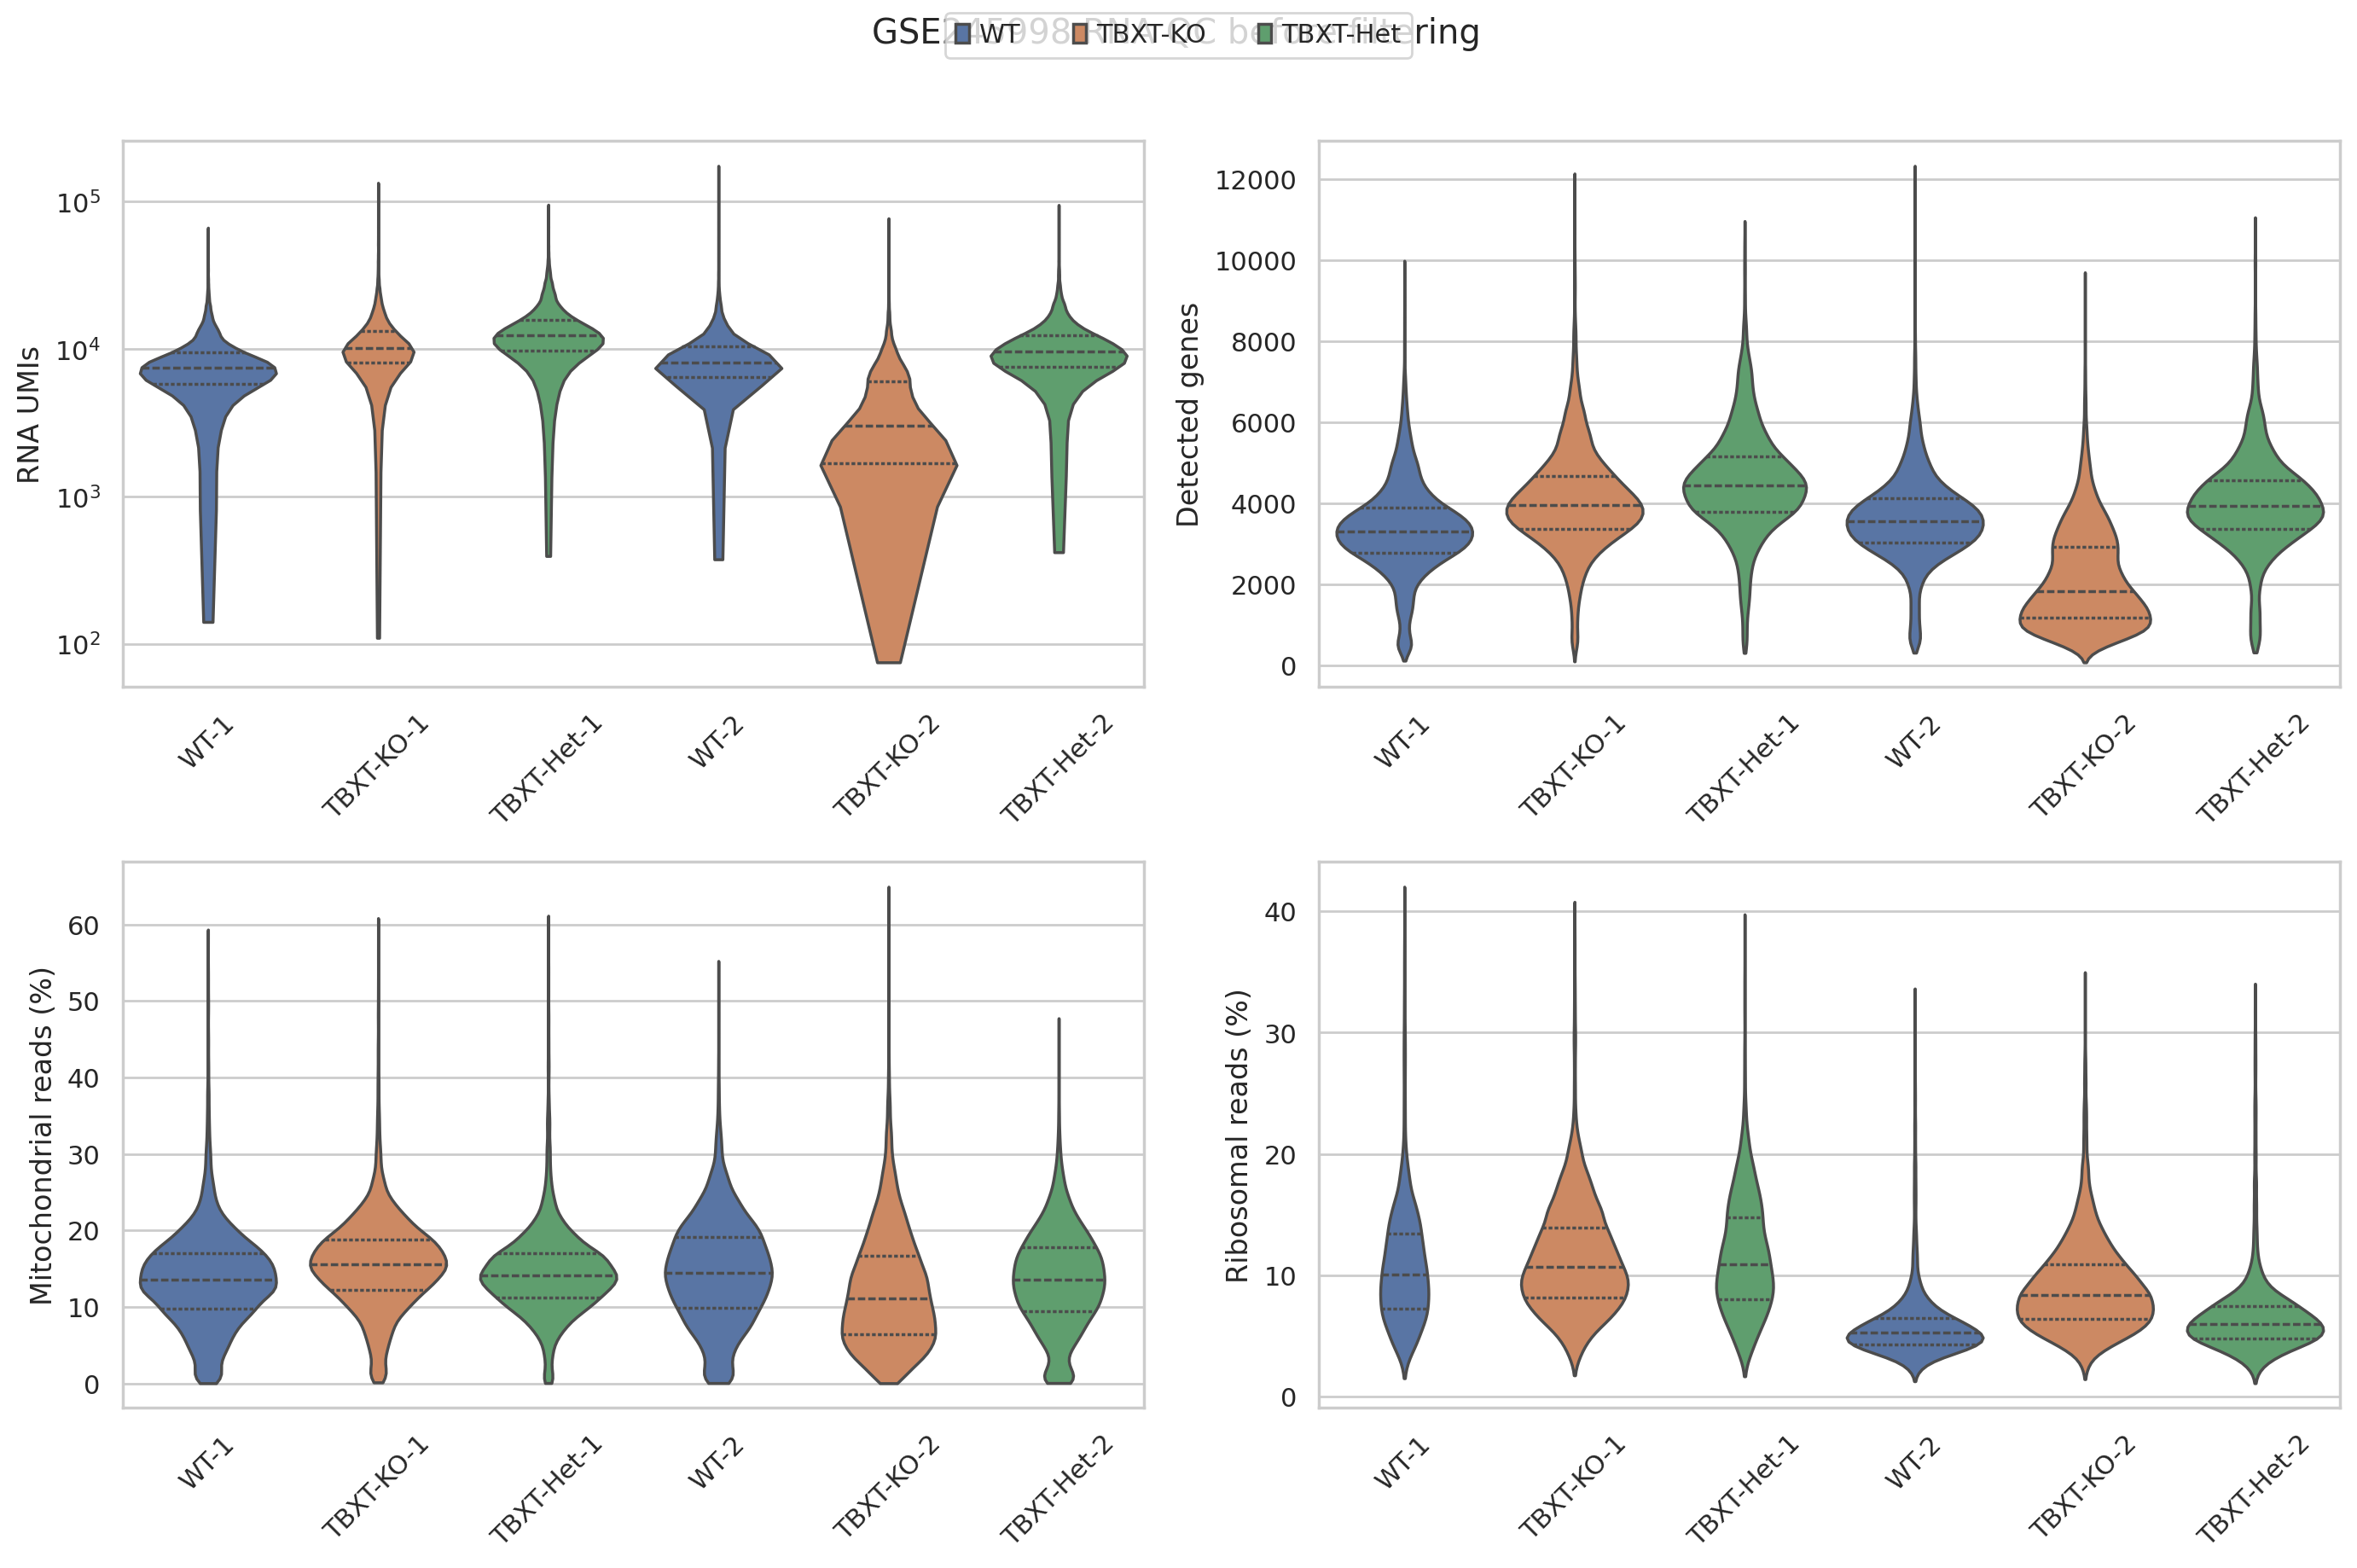

In [31]:
rna_obs = pd.concat([adata.obs for adata in rna_by_sample.values()])
atac_obs = pd.concat([adata.obs for adata in atac_qc_by_sample.values()])

rna_metrics = [
    ("total_counts", "RNA UMIs", True),
    ("n_genes_by_counts", "Detected genes", False),
    ("pct_counts_mt", "Mitochondrial reads (%)", False),
    ("pct_counts_ribo", "Ribosomal reads (%)", False),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (column, label, log_scale) in zip(axes.flat, rna_metrics):
    sns.violinplot(
        data=rna_obs,
        x="sample_name",
        y=column,
        hue="genotype",
        dodge=False,
        cut=0,
        inner="quart",
        ax=ax,
    )
    if log_scale:
        ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=45)
    if ax.legend_ is not None:
        ax.legend_.remove()
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("GSE245998 RNA QC before filtering", y=1.02)
fig.tight_layout()


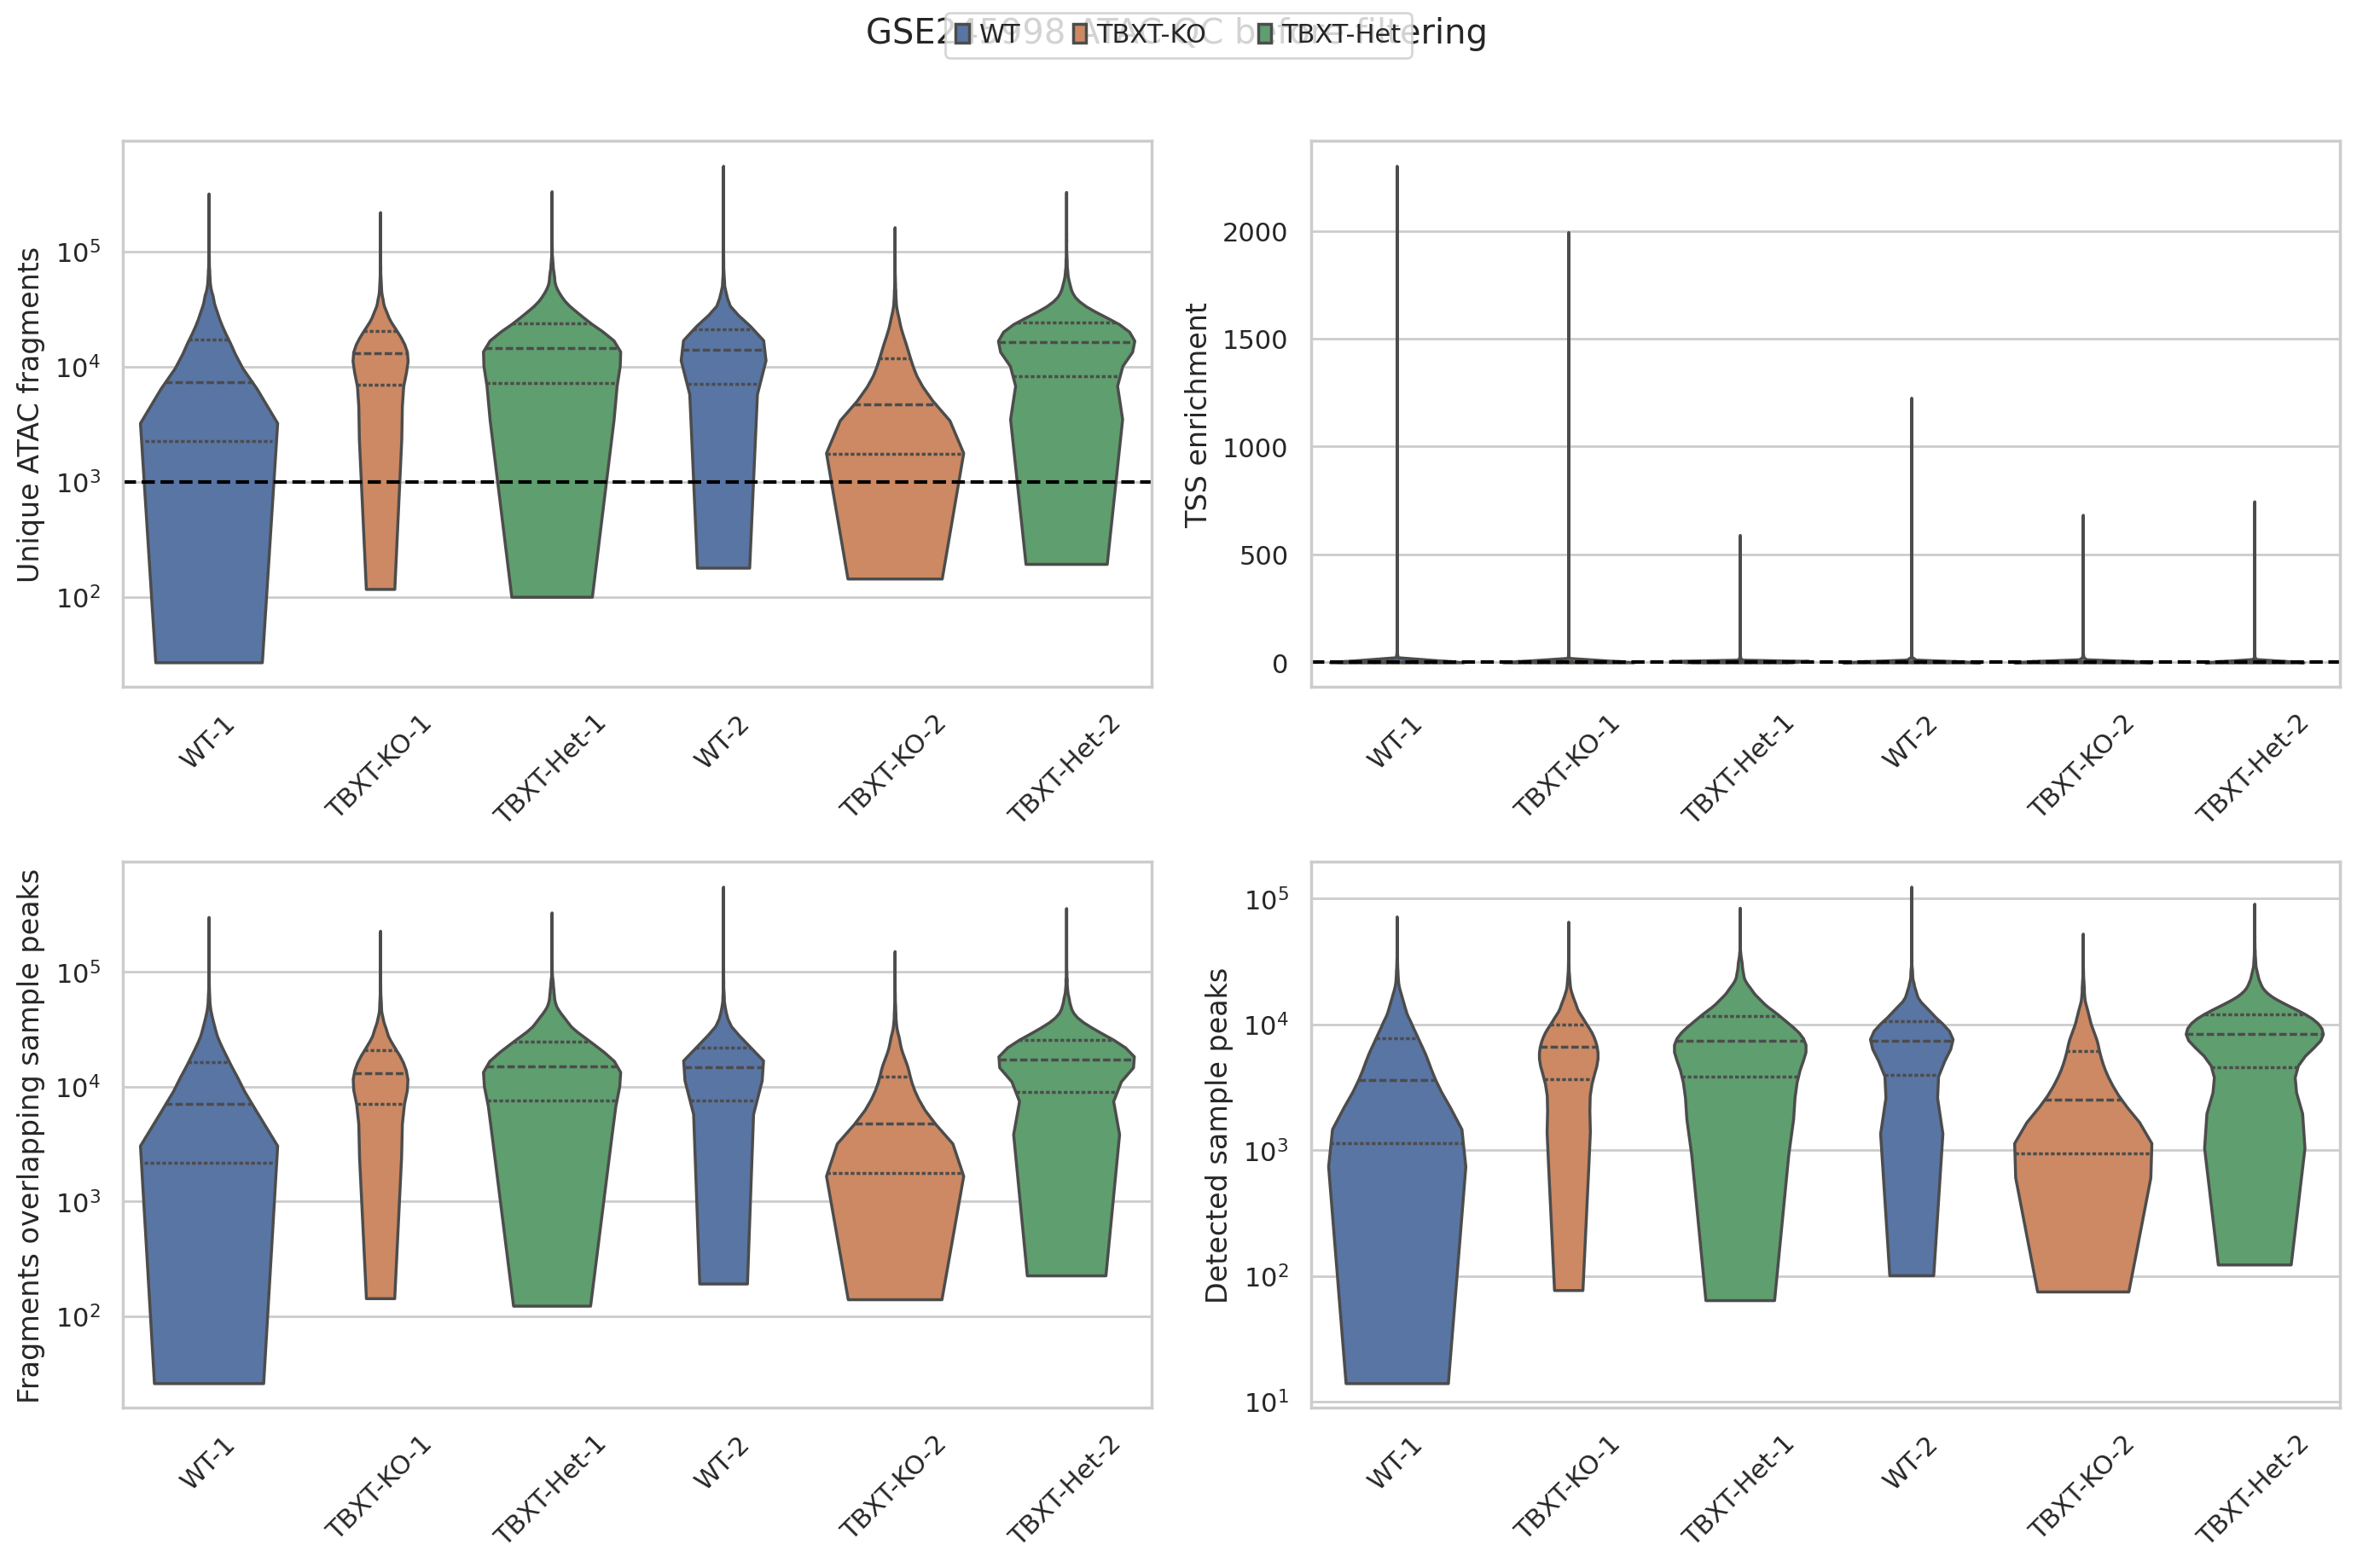

In [32]:
if RUN_FRAGMENT_QC:
    atac_metrics = [
        ("n_fragments", "Unique ATAC fragments", True),
        ("nucleosome_signal", "Mononucleosome / nucleosome-free", False),
        ("total_counts", "Fragments overlapping sample peaks", True),
        ("n_genes_by_counts", "Detected sample peaks", True),
    ]
    if RUN_TSS_QC:
        atac_metrics[1] = ("tss_score", "TSS enrichment", False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, (column, label, log_scale) in zip(axes.flat, atac_metrics):
        sns.violinplot(
            data=atac_obs,
            x="sample_name",
            y=column,
            hue="genotype",
            dodge=False,
            cut=0,
            inner="quart",
            ax=ax,
        )
        if log_scale:
            ax.set_yscale("log")
        if column == "n_fragments":
            ax.axhline(ATAC_QC["min_fragments"], color="black", linestyle="--")
        if column == "tss_score":
            ax.axhline(ATAC_QC["min_tss"], color="black", linestyle="--")
        ax.set_xlabel("")
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=45)
        if ax.legend_ is not None:
            ax.legend_.remove()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    fig.suptitle("GSE245998 ATAC QC before filtering", y=1.02)
    fig.tight_layout()


## Build paired masks and inspect retention


In [33]:
rna_all = ad.concat(
    rna_by_sample,
    axis=0,
    join="inner",
    merge="same",
    index_unique=None,
)
atac_qc_all = ad.concat(
    atac_qc_by_sample,
    axis=0,
    join="inner",
    merge="same",
    index_unique=None,
)
assert rna_all.obs_names.equals(atac_qc_all.obs_names)

selected_rna_column = (
    "pass_author_rna_qc" if QC_PROFILE == "author" else "pass_basic_rna_qc"
)
paired_obs = rna_all.obs.copy()
atac_metric_columns = {
    "n_genes_by_counts": "atac_n_peaks_by_counts",
    "total_counts": "atac_peak_counts",
    "n_fragments": "atac_n_fragments",
    "nucleosome_signal": "atac_nucleosome_signal",
    "tss_score": "atac_tss_score",
}
for source_column, output_column in atac_metric_columns.items():
    if source_column in atac_qc_all.obs:
        paired_obs[output_column] = atac_qc_all.obs[source_column]
paired_obs["pass_atac_qc"] = atac_qc_all.obs["pass_atac_qc"].astype(bool)
paired_obs["pass_doublet_qc"] = ~paired_obs["predicted_doublet"].astype(bool)
paired_obs["pass_paired_qc"] = (
    paired_obs[selected_rna_column].astype(bool)
    & paired_obs["pass_atac_qc"]
    & paired_obs["pass_doublet_qc"]
)

retention = (
    paired_obs.groupby(
        ["sample", "sample_name", "genotype", "batch"],
        observed=True,
    )
    .agg(
        input_cells=("pass_paired_qc", "size"),
        pass_rna=(selected_rna_column, "sum"),
        pass_atac=("pass_atac_qc", "sum"),
        predicted_doublets=("predicted_doublet", "sum"),
        pass_paired=("pass_paired_qc", "sum"),
    )
    .reset_index()
)
retention["paired_retention_pct"] = (
    100 * retention["pass_paired"] / retention["input_cells"]
)
retention


,sample,sample_name,genotype,batch,input_cells,pass_rna,pass_atac,predicted_doublets,pass_paired,paired_retention_pct
0,eb01,WT-1,WT,1,12072,6200,9260,12,4748,39.330683
1,eb02,TBXT-KO-1,TBXT-KO,1,10242,3619,8789,6,3081,30.082015
2,eb03,TBXT-Het-1,TBXT-Het,1,8819,2149,7696,1,1825,20.693956
3,eb06,WT-2,WT,2,10903,5631,9494,29,4900,44.941759
4,eb07,TBXT-KO-2,TBXT-KO,2,19325,3914,13688,0,3322,17.190168
5,eb08,TBXT-Het-2,TBXT-Het,2,8863,4240,7820,12,3728,42.062507


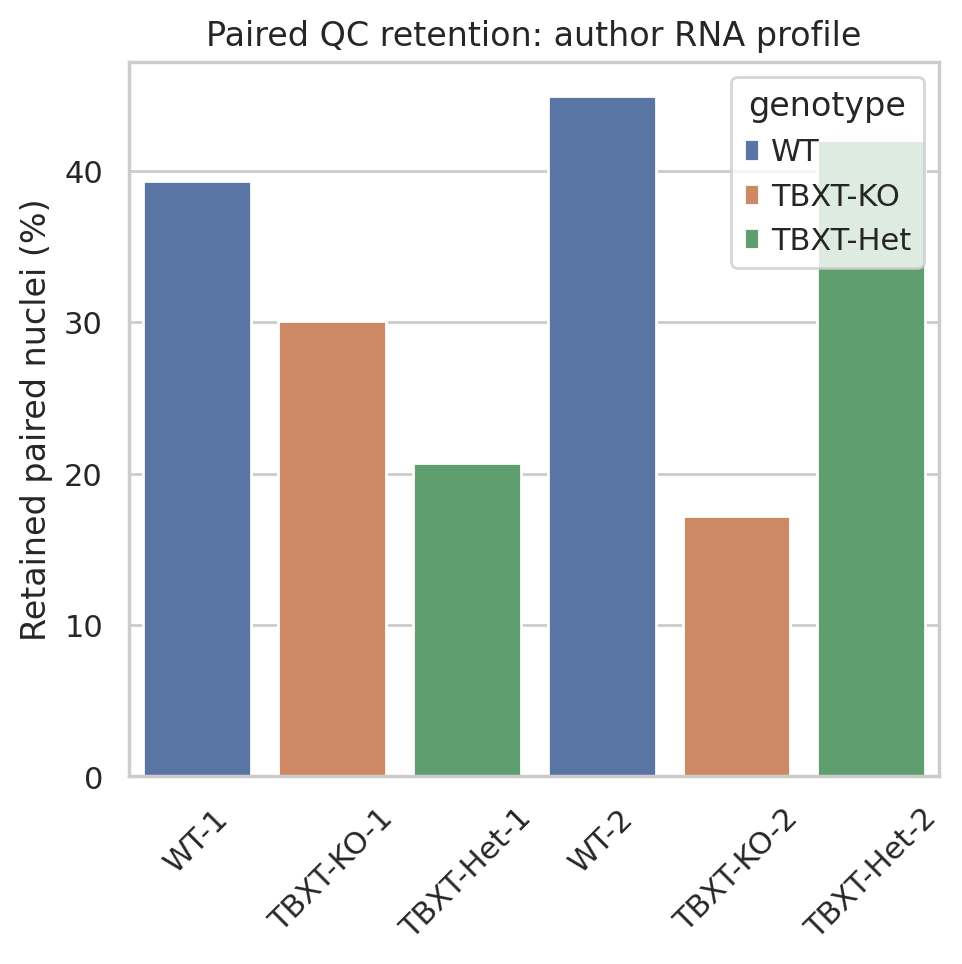

In [34]:
ax = sns.barplot(
    data=retention,
    x="sample_name",
    y="paired_retention_pct",
    hue="genotype",
    dodge=False,
)
ax.set_xlabel("")
ax.set_ylabel("Retained paired nuclei (%)")
ax.tick_params(axis="x", rotation=45)
ax.set_title(f"Paired QC retention: {QC_PROFILE} RNA profile")
plt.tight_layout()


## Create the QC objects

Raw integer counts remain in `rna_qc.X`; normalization and feature selection belong in
the next notebook. The ATAC modality here intentionally contains only cell metadata.
Its retained barcode files and fragment paths are the inputs for consensus peak or
fixed-bin matrix construction.


In [35]:
keep = paired_obs["pass_paired_qc"]
kept_names = paired_obs.index[keep]

rna_qc = rna_all[kept_names].copy()
rna_qc.obs = paired_obs.loc[kept_names].copy()
sc.pp.filter_genes(rna_qc, min_cells=3)

atac_cell_qc = atac_qc_all[kept_names].copy()
atac_cell_qc.obs = paired_obs.loc[kept_names].copy()
atac_cell_qc.uns["fragment_files"] = {
    sample: str(Path(row.fragments).resolve())
    for sample, row in sample_manifest.iterrows()
}
atac_cell_qc.uns["feature_space_note"] = (
    "obs-only QC object; construct a consensus peak or fixed-bin matrix from fragments"
)

provenance = {
    "geo_accession": "GSE245998",
    "paper_doi": "10.1242/dev.202516",
    "author_code": "https://github.com/ebulger3/TBXT-CDX2-Analysis",
    "qc_profile": QC_PROFILE,
    "author_rna_qc": AUTHOR_RNA_QC,
    "basic_rna_qc": BASIC_RNA_QC,
    "atac_qc": ATAC_QC,
    "tss_method": "muon ENCODE-style enrichment with GENCODE v32 gene TSS",
    "doublet_method": "scanpy.pp.scrublet per sample after RNA QC",
}
rna_qc.uns["provenance"] = provenance
atac_cell_qc.uns["provenance"] = provenance

multiome_qc = md.MuData({"rna": rna_qc, "atac_qc": atac_cell_qc})
multiome_qc.obs = paired_obs.loc[kept_names].copy()
multiome_qc.uns["provenance"] = provenance

print(rna_qc)
print(atac_cell_qc)
print(multiome_qc)


filtered out 7003 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 21604 × 29598
    obs: 'barcode', 'sample', 'sample_name', 'genotype', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'pass_author_rna_qc', 'pass_basic_rna_qc', 'doublet_score', 'predicted_doublet', 'atac_n_peaks_by_counts', 'atac_peak_counts', 'atac_n_fragments', 'atac_nucleosome_signal', 'atac_tss_score', 'pass_atac_qc', 'pass_doublet_qc', 'pass_paired_qc'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'gene_symbol', 'mt', 'ribo', 'n_cells'
    uns: 'provenance'
AnnData object with n_obs × n_vars = 21604 × 0
    obs: 'barcode', 'sample', 'sample_name', 'genotype', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'pass_author_rna_qc', 'pass_basic_rna_qc', 'doublet_score', 'predicted_doublet', 'atac_n_peaks_by_counts', 'atac_peak

/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Write outputs


In [36]:
if WRITE_OUTPUTS:
    rna_path = OUTPUT_DIR / "gse245998_rna_qc.h5ad"
    atac_qc_path = OUTPUT_DIR / "gse245998_atac_cell_qc.h5ad"
    mudata_path = OUTPUT_DIR / "gse245998_multiome_qc.h5mu"
    retention_path = OUTPUT_DIR / "gse245998_qc_retention.csv"

    rna_qc.write_h5ad(rna_path, compression="gzip")
    atac_cell_qc.write_h5ad(atac_qc_path, compression="gzip")
    multiome_qc.write_h5mu(mudata_path)
    retention.to_csv(retention_path, index=False)

    for sample in sample_manifest.index:
        sample_barcodes = rna_qc.obs.loc[
            rna_qc.obs["sample"] == sample, "barcode"
        ]
        sample_barcodes.to_csv(
            BARCODE_DIR / f"{sample}_retained_barcodes.txt",
            index=False,
            header=False,
        )

    for path in (rna_path, atac_qc_path, mudata_path, retention_path):
        print(path.relative_to(REPO), f"{path.stat().st_size / 1e6:.1f} MB")
else:
    print("Smoke-test mode: outputs were not written.")


data/GSE245998/processed/gse245998_rna_qc.h5ad 178.3 MB
data/GSE245998/processed/gse245998_atac_cell_qc.h5ad 2.8 MB
data/GSE245998/processed/gse245998_multiome_qc.h5mu 644.7 MB
data/GSE245998/processed/gse245998_qc_retention.csv 0.0 MB


/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/stan/Git/micropattern/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Next notebook

The next analysis should construct one shared chromatin feature space from the retained
fragments, preferably:

1. a 500 bp tile matrix for unbiased QC/LSI and initial clustering, matching the authors'
   ArchR strategy; then
2. reproducible sample- or cluster-aware peak calling followed by a consensus peak matrix.

Only after that step should RNA and ATAC representations be integrated (for example with
MultiVI or a WNN-style graph) and the PGC/PGCLC compartment identified.
